# Effects of dataset shape on DP sums

Differential privacy works best on datasets that are "tall and skinny":
They have a lot of rows, but only a small number of columns under analysis.
Having more rows means that the contribution of any particular row is smaller,
and having fewer columns reveals less information for every row.

But how tall is tall enough? And how many columns is too many columns?
In this notebook we'll demonstrate DP sums on different kinds of datasets.

In [1]:
import matplotlib.pyplot as plt
import opendp.prelude as dp
import polars as pl

In [2]:
# The OpenDP team is working to vet the core algorithms.
# Until that is complete we need to opt-in to use these features.
dp.enable_features("contrib")

For this example, we'll just use constant data, so the only variation in the results comes from the noise added by DP. We'll make every value 5, perhaps in a range between 0 and 10. (But we'll look at the effects of this range assumption later.)

In [3]:
def make_fives_lf(rows, cols):
    """
    Makes a lazyframe with the specified rows and column, filled with fives.
    """
    return pl.LazyFrame({f"col_{i + 1}": (5 for _ in range(rows)) for i in range(cols)})

These values will be constant in every example:

In [4]:
MAX_ROWS_LOG_10 = 5
MAX_COLS_LOG_2 = 5

Let's see how well DP sums work on datasets of different dimensions:

In [5]:
def key(rows, cols):
    return f"{rows=} {cols=}"

In [6]:
def get_results_accuracies(plus_minus=5, epsilon=1.0):
    results = {}
    accuracies = {}

    for rows_log_10 in range(1, MAX_ROWS_LOG_10):
        rows = 10**rows_log_10
        for cols_log_2 in range(MAX_COLS_LOG_2):
            cols = 2**cols_log_2
            context = dp.Context.compositor(
                data=make_fives_lf(rows=rows, cols=cols),
                privacy_unit=dp.unit_of(contributions=1),
                privacy_loss=dp.loss_of(epsilon=epsilon, delta=0),
                split_by_weights=[1],
                margins=[
                    # We'll assume that we know the size of the dataset.
                    dp.polars.Margin(max_length=rows),
                ],
            )

            col_queries = [
                # Values are clipped by plus_minus.
                pl.col(f"col_{i + 1}").dp.sum((5 - plus_minus, 5 + plus_minus))
                for i in range(cols)
            ]
            query = context.query().select(*col_queries)
            accuracy = query.summarize(alpha=0.05)["accuracy"][0]

            k = key(rows, cols)
            accuracies[k] = accuracy
            print(key(rows, cols), accuracy)
            results[k] = query.release().collect()

    return results, accuracies

In [7]:
results, accuracies = get_results_accuracies()

rows=10 cols=1 30.444827940403663


rows=10 cols=2 60.408396122013016


rows=10 cols=4 120.32616602353652


rows=10 cols=8 240.15701939449175


rows=10 cols=16 479.8163825199104


...

rows=10000 cols=1 30.444827940403663


rows=10000 cols=2 60.408396122013016


rows=10000 cols=4 120.32616602353652


rows=10000 cols=8 240.15701939449175


rows=10000 cols=16 479.8163825199104


In [8]:
def plot(results, accuracies):
    _fig, axs = plt.subplots(MAX_ROWS_LOG_10 - 1, MAX_COLS_LOG_2)

    for rows_log_10 in range(1, MAX_ROWS_LOG_10):
        rows = 10**rows_log_10
        for cols_log_2 in range(MAX_COLS_LOG_2):
            cols = 2**cols_log_2
            values = results[key(rows, cols)].to_dicts()[0].values()
            ax = axs[rows_log_10 - 1, cols_log_2]
            ax.bar(range(cols), values, yerr=accuracies[key(rows, cols)])
            ax.set_xticks([])
            ax.set_yticks(
                [0, rows * 5], labels=[0, rows * 5] if cols == 1 else ["", ""]
            )

    plt.show()

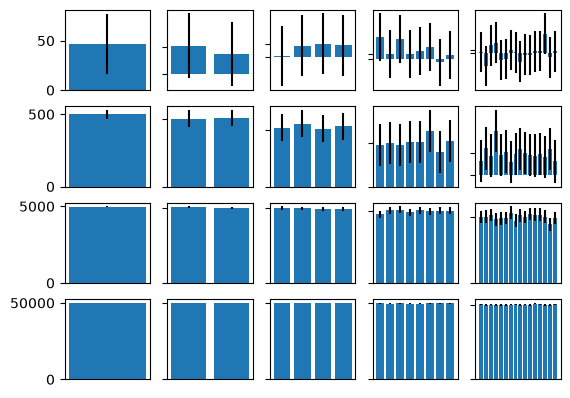

In [9]:
plot(results, accuracies)

As you can see, with smaller numbers of rows, and larger numbers of columns,
the accuracy of the sum declines: with each row making a larger contribution
to the final statistic, more noise is necessary to hide individual contributions.

Are there strategies we can use to improve our results? Yes!
Most obviously, make fewer queries. This about the questions that are really immportant to you,
and your privacy budget can go farther.

Another option when working with sums or means is to adjust the clipping bounds.
In this example we assumed the values could range between 0 and 10. What if we narrow the range?
If there were outliers, the results would be biases, but if we are confident that values
lie in a smaller range, we can get more accurate results.

In [10]:
results, accuracies = get_results_accuracies(
    plus_minus=1
)  # 4 to 6, instead of 0 to 10.

rows=10 cols=1 18.4535843760858


rows=10 cols=2 36.43837362866836


rows=10 cols=4 72.3923666086791


rows=10 cols=8 144.29254501101863


rows=10 cols=16 288.0889961837368


...

rows=10000 cols=1 18.4535843760858


rows=10000 cols=2 36.43837362866836


rows=10000 cols=4 72.3923666086791


rows=10000 cols=8 144.29254501101863


rows=10000 cols=16 288.0889961837368


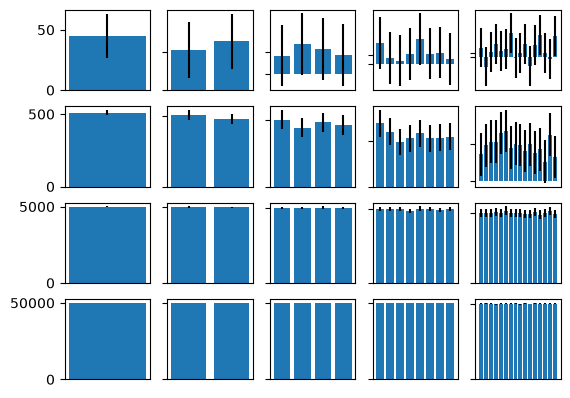

In [11]:
plot(results, accuracies)

Another option is to use a larger or smaller privacy budget. If you have a large number of contributors,
or a small number of queries, you might use an epsilon much less than 1 and still have sufficiently
accurate results.

In [12]:
results, accuracies = get_results_accuracies(
    epsilon=0.05
)  # 1/20th of the original budget.

rows=10 cols=1 599.6458297114494


rows=10 cols=2 1198.792596921678


rows=10 cols=4 2397.0856625932033


rows=10 cols=8 4793.671559561389


rows=10 cols=16 9586.84323631028


...

rows=10000 cols=1 599.6458297114494


rows=10000 cols=2 1198.792596921678


rows=10000 cols=4 2397.0856625932033


rows=10000 cols=8 4793.671559561389


rows=10000 cols=16 9586.84323631028


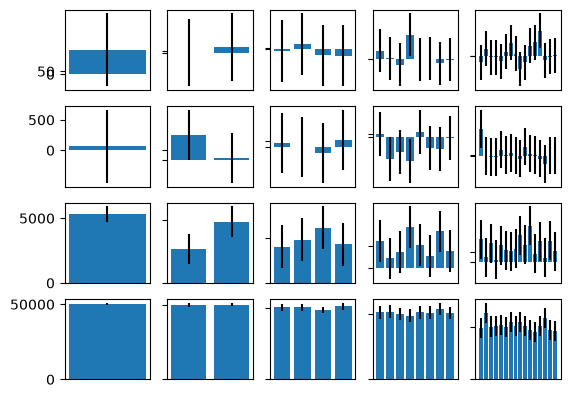

In [13]:
plot(results, accuracies)

While this wouldn't be useful for small datasets, with 10,000 rows the results are still good!